# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Eszter B. Bartucz
* Username: ebbartucz
* Student number: s6362311
* Group (AS1, etc.): AS4

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

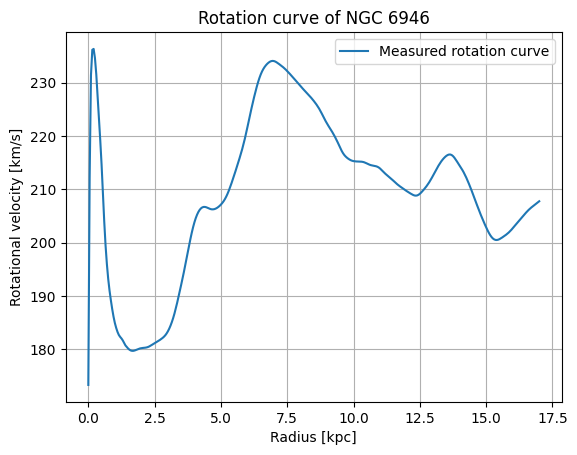

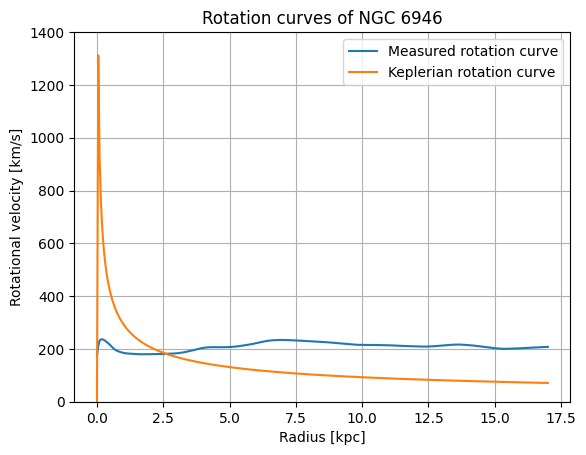

In [2]:
import numpy as np
from math import sqrt
from scipy.constants import G
import matplotlib.pyplot as plt
from pathlib import Path
import os

M_star = 2*10**10*1.988*10**30 # multiplied by solar mass so now in kg

tilde_path = os.path.expanduser('~') # this formulation of the path is necessary because I am working on a windows machine
subdirectory = 'PROGNUM-repo/Task5'
filename1 = "rotcur.dat"
OSpath1 = f"{tilde_path}/{subdirectory}/{filename1}"

radius, rotation_velocity = np.loadtxt(OSpath1, unpack = True) # loading the data in the provided text file

plt.plot(radius, rotation_velocity, label = f"Measured rotation curve")
plt.title("Rotation curve of NGC 6946")
plt.xlabel("Radius [kpc]")
plt.ylabel("Rotational velocity [km/s]")
plt.grid()
plt.legend()
plt.show()

v = []
for r in radius:
    if r == 0:
        v.append(0) # for zero radius, the formula below would yield math error, so we input manually that the velocity in the center is zero
    else:
        v.append(sqrt(G*M_star/(r*1000*3.086*10**16))/1000) # the velocity calculated from the given formula
        
v = np.array(v) # converting the list into an array for future operations

keplerian = list(zip(radius,v)) # this way it is possible to save multiple arrays into one text file
np.savetxt('keplerian_curve.txt',keplerian)

tilde_path = os.path.expanduser('~') # this formulation of the path is necessary because I am working on a windows machine
subdirectory = 'PROGNUM-repo/Task5'
filename2 = "keplerian_curve.txt"
OSpath2 = f"{tilde_path}/{subdirectory}/{filename2}"

radius2, velocity2 = np.loadtxt(OSpath2, unpack = True) # loading the Keplerian text file

plt.plot(radius, rotation_velocity, label = f"Measured rotation curve")
plt.plot(radius2, velocity2, label = f"Keplerian rotation curve")
plt.title("Rotation curves of NGC 6946")
plt.xlabel("Radius [kpc]")
plt.ylabel("Rotational velocity [km/s]")
plt.ylim(0,1400) # fixing the limits of the y axis
plt.grid()
plt.legend()
plt.show()

# comment: since the measured curve does not align with the predictions of Kepler, we must conclude that the galaxy does not follow a Keplerian rotation

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

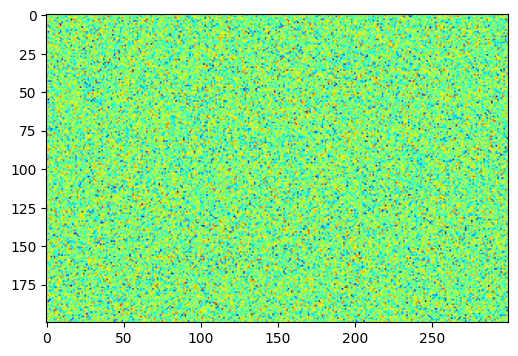

The mean of the arbitrary slice is: -0.017191091569279622, while the standard deviation is 0.9749198445510868.


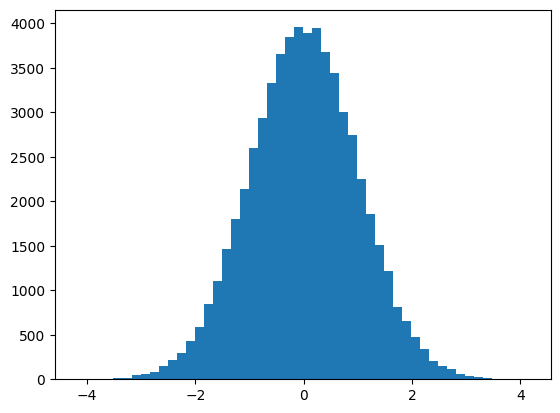

Since the data was created using np.random.normal, it is natural that a histogram of the data yields a Gaussian curve i.e. normal distribution.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow, cm

fig1 = plt.figure(figsize = (8,4)) # specifying the dimensions of the image
M = np.random.normal(0.0,1.0,60000) # first creating the distribution
M.shape = (200,300) # reshaping into the required shape
plt.imshow(M, cmap = 'jet') # plotting with jet color map
plt.show()

s = M[100:130,150:180] # creating an arbitrary matrix of 30x30 pixels near the middle of the picture
sflat = s.flatten() # flattening the array to calculate its parameters
mean = sflat.mean()
stdev = sflat.std()

print(f"The mean of the arbitrary slice is: {mean}, while the standard deviation is {stdev}.")
# These values lie close to the values of the created normal distribution. 
# The difference can be explained by taking a sample from the distribution rather than using the whole distribution
# as well as the fact that the slice is not exactly in the center of the picture which would yield the mean of the original distribution.

fig2 = plt.figure() # new figure to separate from previous
plt.hist(M.flatten(), bins = 50) # using the flattened data and 50 bins
plt.show()

print("Since the data was created using np.random.normal, it is natural that a histogram of the data yields a Gaussian curve i.e. normal distribution.")

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

The perimeter is 15.865439589251233 and the area is 18.84955592153876.
The coordinates of the center of the ellipse are: (0, 0), the semi major axis is 3.0 while the semi minor axis is 2.0. The position angle is 0 degrees.


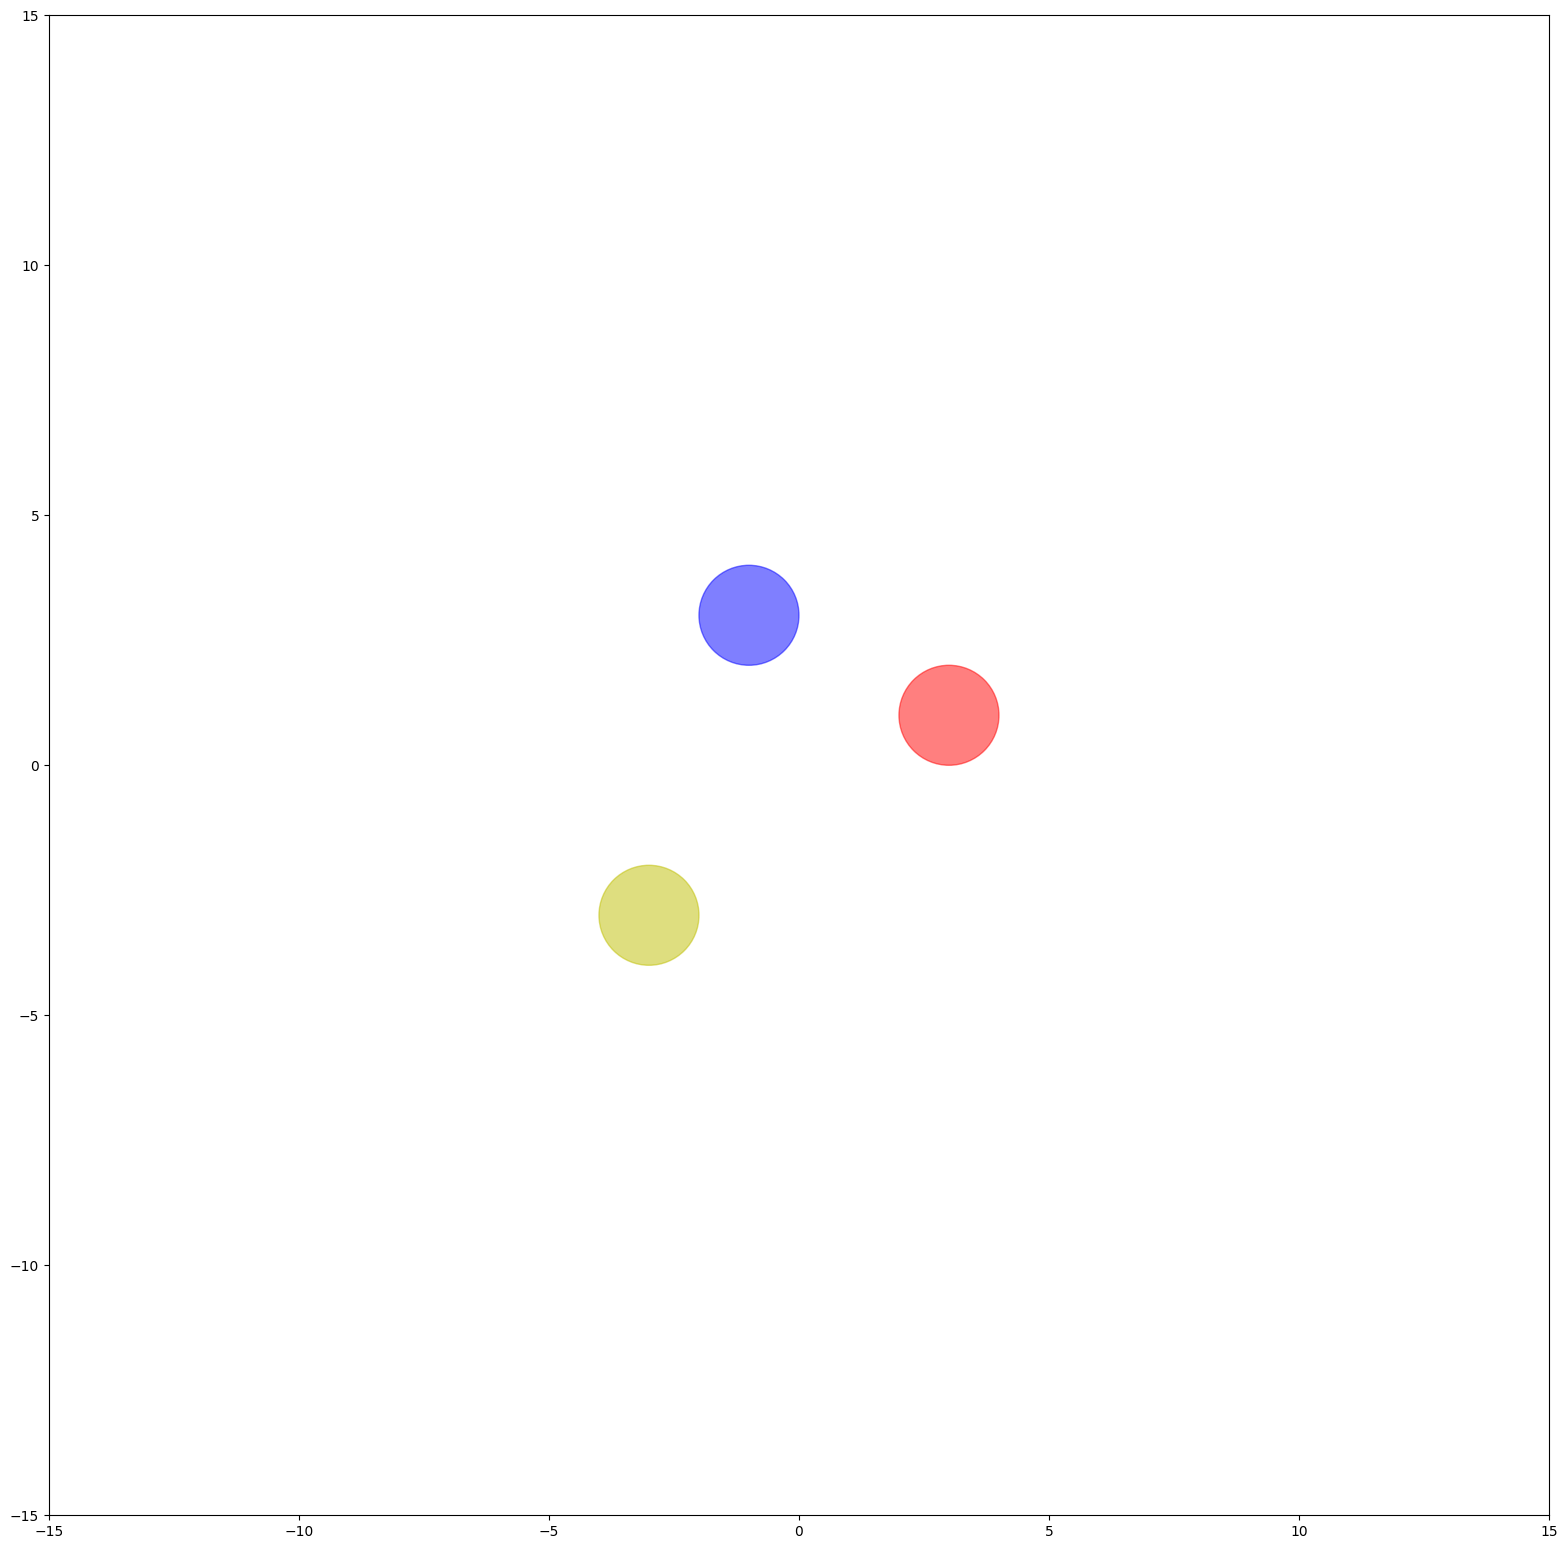

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from math import sqrt
import numpy as np
from numpy import pi

class AstroEllipse(Ellipse):
    pi = np.pi
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      self.XY = (xc, yc)                  # MPL requires center as a tuple
      self.angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(self.XY, width, height, angle=self.angle_mpl, **args)
    def area(self):
        '''
        Calculates the area of an ellipse.
        Params: semi_major (float), semi_minor (float), pi (constant,float)
        Return: area (float) 
        '''
        area = self.height*self.width*pi/4
        return area
    def perimeter(self):
        '''
        Calculates the perimeter of an ellipse using Ramanujan’s second approximation.
        Params: semi_major (float), semi_minor (float), pi (constant,float)
        Return: area (float) 
        '''
        a = self.height/2 # for ease of writing the formula
        b = self.width/2
        h = (a-b)**2/(a+b)**2
        perimeter = pi*(a+b)*(1+(3*h)/(10+sqrt(4-3*h)))
        return perimeter
    def __str__(self):
        return f"The coordinates of the center of the ellipse are: {self.XY}, the semi major axis is {self.height/2} while the semi minor axis is {self.width/2}. The position angle is {self.angle_mpl} degrees."


ellipse = AstroEllipse(0,0,3,2,0)
print(f"The perimeter is {ellipse.perimeter()} and the area is {ellipse.area()}.")

print(ellipse.__str__())

class MyCircle(AstroEllipse): # ensuring that new class inherits from AstroEllipse
    def __init__(self, xc, yc, radius, **args):
        AstroEllipse.__init__(self,xc,yc,radius,radius,0,**args)


circle1 = MyCircle(np.random.randint(-5,5),np.random.randint(-5,5),np.random.randint(1,5), color = 'r', alpha = 0.5) # choosing the parameters randomly
circle2 = MyCircle(np.random.randint(-5,5),np.random.randint(-5,5),np.random.randint(1,5), color = 'b', alpha = 0.5) # from a set range
circle3 = MyCircle(np.random.randint(-5,5),np.random.randint(-5,5),np.random.randint(1,5), color = 'y', alpha = 0.5)

fig = plt.figure(figsize = (1,1))
frame = fig.add_axes([-15,-15,15,15]) # creating frame

frame.add_patch(circle1) # adding the circles
frame.add_patch(circle2)
frame.add_patch(circle3)

frame.set_xlim(-15,15) # ensuring axis limits
frame.set_ylim(-15,15)
plt.show()


In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

/tmp/ipykernel_2536631/3654888718.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


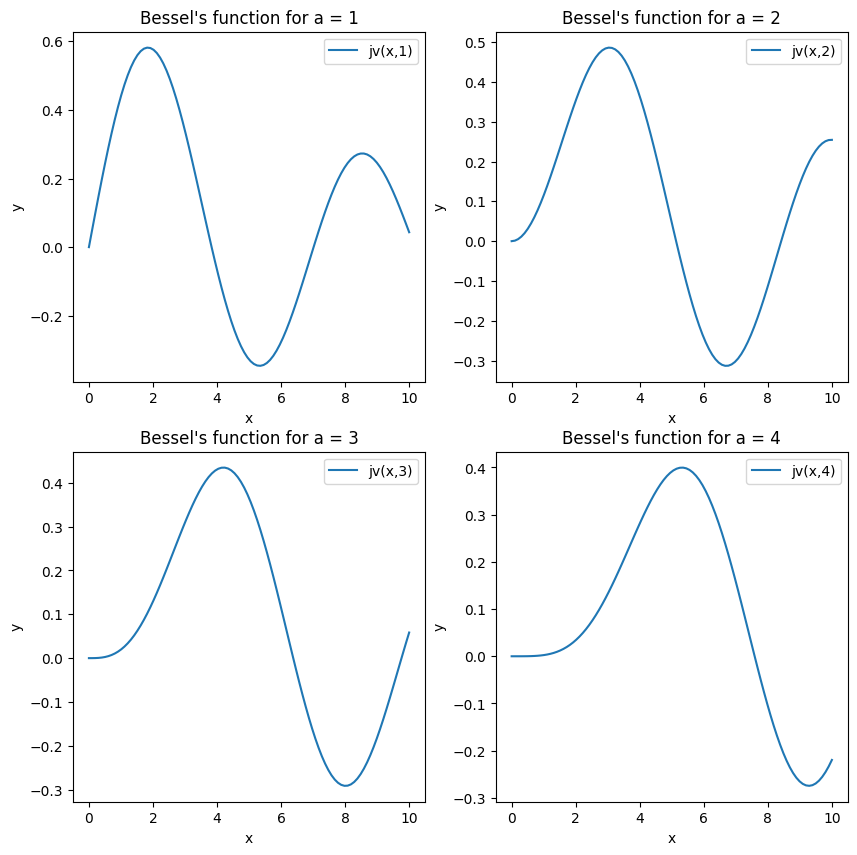

In [8]:
from scipy.special import jv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

a = [1,2,3,4]
x = np.linspace(0,10,100) # creating the domain of the function

b1 = jv(a[0],x) # calculating the values for every element in the domain with the given method
b2 = jv(a[1],x)
b3 = jv(a[2],x)
b4 = jv(a[3],x)

fig = figure(figsize = (10,10))

frame = fig.add_subplot(2,2,1) # ensuring 2x2 setup
frame.plot(x,b1, label = 'jv(x,1)')
frame.set_title("Bessel's function for a = 1")
frame.set_xlabel("x")
frame.set_ylabel("y")
frame.legend()

frame = fig.add_subplot(2,2,2)
frame.plot(x,b2, label = 'jv(x,2)')
frame.set_title("Bessel's function for a = 2")
frame.set_xlabel("x")
frame.set_ylabel("y")
frame.legend()

frame = fig.add_subplot(2,2,3)
frame.plot(x,b3,label = 'jv(x,3)')
frame.set_title("Bessel's function for a = 3")
frame.set_xlabel("x")
frame.set_ylabel("y")
frame.legend()

frame = fig.add_subplot(2,2,4)
frame.plot(x,b4,label = 'jv(x,4)')
frame.set_title("Bessel's function for a = 4")
frame.set_xlabel("x")
frame.set_ylabel("y")
frame.legend()
fig.show()

fig.savefig('bessel.png',transparent = True) # this line saves the figure as a transparent png


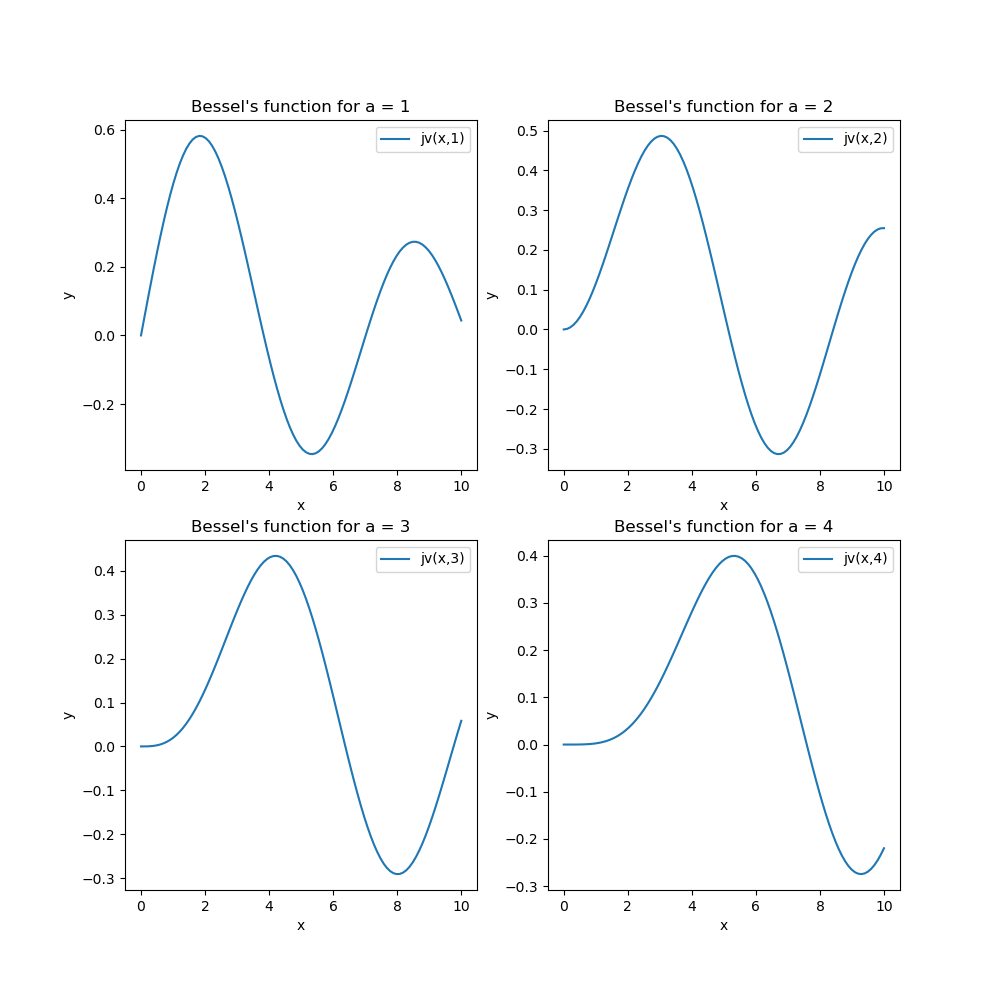


If this image should not load, please find it in my GitHub repository with the name 'bessel.png' on the link: https://github.com/ebbartucz/PROGNUM-repo.git

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

/tmp/ipykernel_2536631/3701021848.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


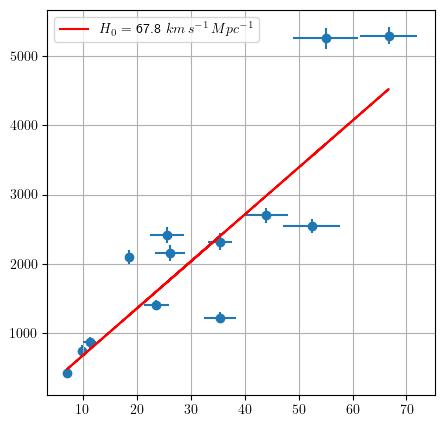

In [10]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np

H_0 = 67.8 

data = [
18.49,     2094.75,    0.3,           100,
35.48,     2320.87,    2.2,           120,
35.48,     1224.9,     3.0,           80,
11.34,     872.13,     1.2,           80,
7.12,      432.2,      0.4,           70,
9.82,      751,        0.3,           75,
23.66,     1410,       2.3,           70,
44,        2700,       4.0,           110,
66.7,      5292,       5.3,           120,
52.4,      2550,       5.2,           100,
55,        5253,       6.1,           150,
25.6,      2419,       3.2,           110,
26.19,     2158,       2.8,           110
]

d = data[::4] # extracting the columns as separate data sets with slice
v = data[1::4]
dd = data[2::4]
dv = data[3::4]

fig = figure(figsize = (5,5)) 
plt.rc ('text', usetex = True)
frame = fig.add_subplot(1,1,1)
frame.scatter(d,v)
frame.errorbar(d,v,xerr=dd,yerr=dv,fmt='none')
frame.plot(d,H_0*np.array(d),label = rf"$H_0$ = {H_0} "+ "$km\, s^{-1} \,Mpc^{-1}$", color = 'red')
frame.grid()
frame.legend()
fig.show()


In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
